In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [4]:
# Create non-linear dataset
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

# Split & scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# Plot a activation function
def plot_activation(func,name,x_range=(-5,5)):
    x = np.linspace(*x_range,200)
    y = func(x)
    plt.figure(figsize=(5,4))
    plt.plot(x,y)
    plt.title(f"{name} Activation")
    plt.grid(True)
    plt.show()

In [6]:
def train_and_plot(activation, act_name):
    model = MLPClassifier(
        hidden_layer_sizes=(8,),
        activation=activation,
        solver='adam',
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Decision boundary
    h = .02
    xx, yy = np.meshgrid(
        np.arange(X_train[:, 0].min() - 1, X_train[:, 0].max() + 1, h),
        np.arange(X_train[:, 1].min() - 1, X_train[:, 1].max() + 1, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k')
    plt.title(f"{act_name} - Accuracy: {acc:.2f}")
    plt.show()

    return acc

# Linear Activation Function

In [7]:
def linear(x):
  return x

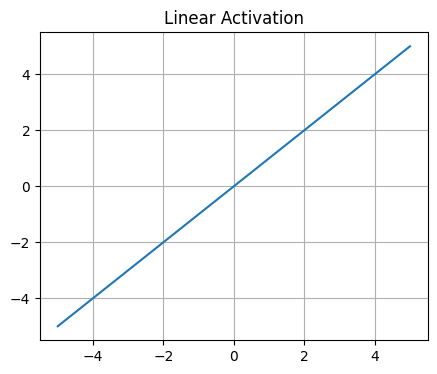

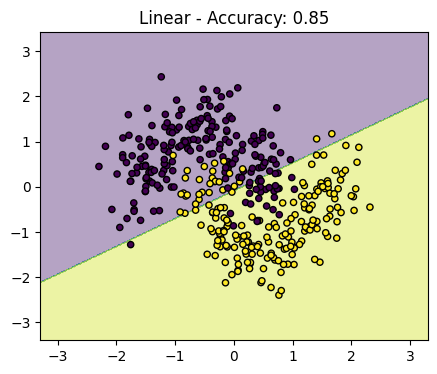

In [8]:
results = {}
plot_activation(linear,"Linear")
results["Linear"] = train_and_plot("identity","Linear")

- Even after 8 neurons in the hidden layers we were not able to classify properly because of **linear activation functin**

In [9]:
import numpy as np

x = np.array([1,2,3])
y = np.array([4,5])

xx, yy = np.meshgrid(x, y)

print(xx)
print(yy)

[[1 2 3]
 [1 2 3]]
[[4 4 4]
 [5 5 5]]


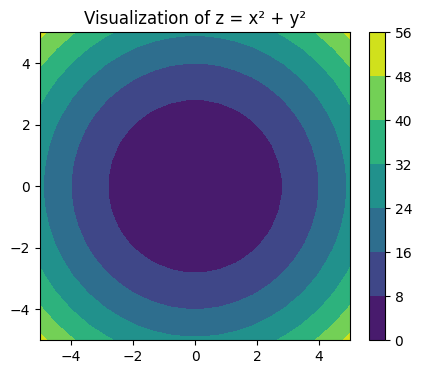

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# create x and y ranges
x = np.linspace(-5, 5, 20)
y = np.linspace(-5, 5, 20)

# create grid
xx, yy = np.meshgrid(x, y)

# function evaluated on grid
z = xx**2 + yy**2

plt.figure(figsize=(5,4))
plt.contourf(xx, yy, z)
plt.colorbar()
plt.title("Visualization of z = x² + y²")
plt.show()

What happens

x → horizontal coordinates

y → vertical coordinates

meshgrid → creates all combinations of (x,y)

z = f(x,y) is computed for every point

Conceptually the grid looks like:

- (x1,y1) (x2,y1) (x3,y1)
- (x1,y2) (x2,y2) (x3,y2)
- (x1,y3) (x2,y3) (x3,y3)

# Sigmoid Activation Function

In [11]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

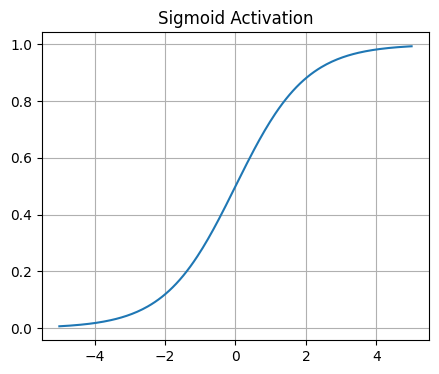

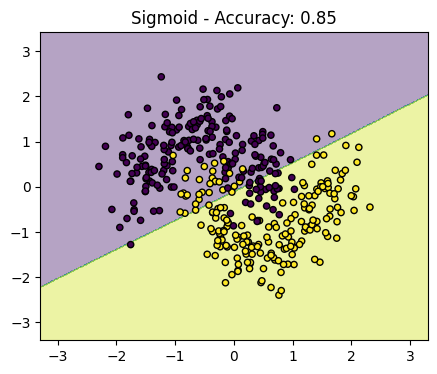

In [12]:
plot_activation(sigmoid,"Sigmoid")
results["Sigmoid"] = train_and_plot("logistic","Sigmoid")

# Tanh Activation

In [13]:
def tanh_fn(x):
    return np.tanh(x)

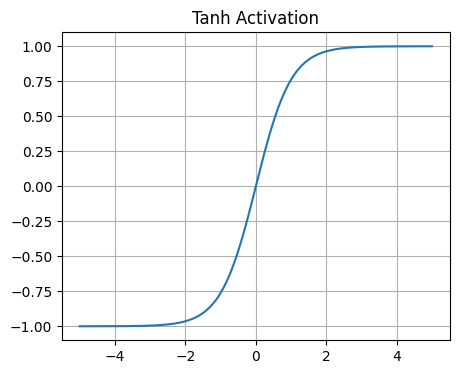

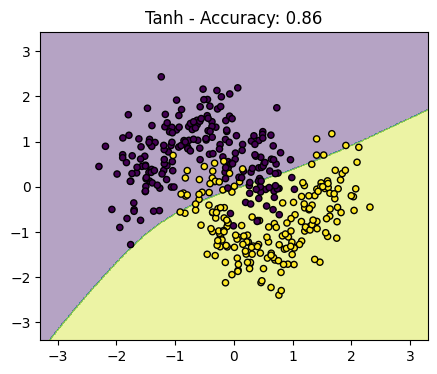

In [14]:
plot_activation(tanh_fn,"Tanh")
results["Tanh"] = train_and_plot("tanh","Tanh")

In [15]:
results

{'Linear': 0.85, 'Sigmoid': 0.85, 'Tanh': 0.86}

# Vanishing Gradient

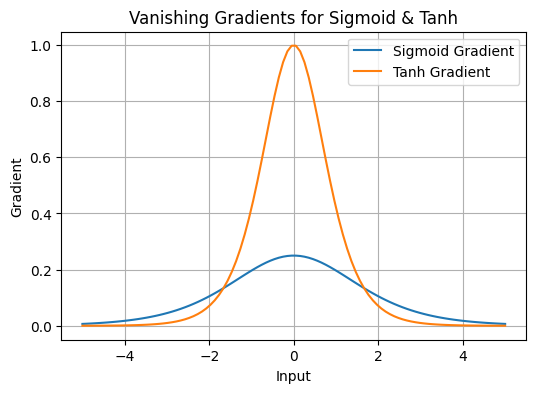

In [16]:
# Simulate gradient shrinkage in deep sigmoid network
x = np.linspace(-5, 5, 100)

grad_sigmoid = sigmoid(x) * (1 - sigmoid(x))
grad_tanh = 1 - np.tanh(x)**2

plt.figure(figsize=(6,4))
plt.plot(x, grad_sigmoid, label='Sigmoid Gradient')
plt.plot(x, grad_tanh, label='Tanh Gradient')

plt.title("Vanishing Gradients for Sigmoid & Tanh")
plt.xlabel("Input")
plt.ylabel("Gradient")

plt.legend()
plt.grid(True)
plt.show()

In [17]:
print(np.tanh(2))

0.9640275800758169


In [18]:
print(sigmoid(2))

0.8807970779778823


# ReLU (Rectifier Linear Unit) Activation Function

In [19]:
def relu(x):
  return np.maximum(0, x)

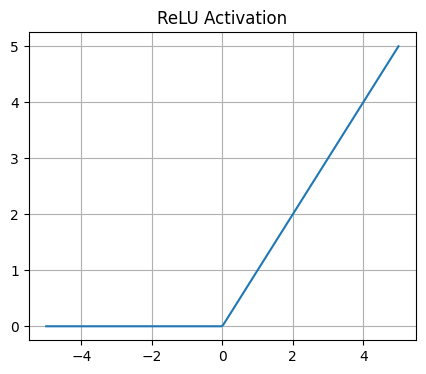

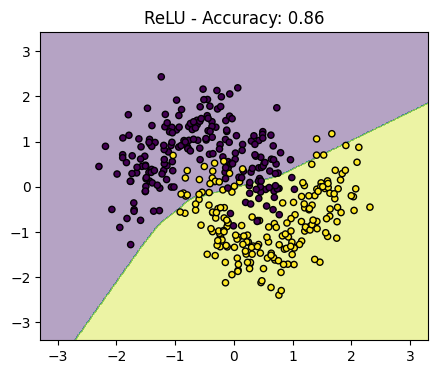

In [20]:
results={}
#4. ReLU Activation
plot_activation(relu, "ReLU")
results['ReLU'] = train_and_plot('relu', 'ReLU')

# Dying ReLU Problem

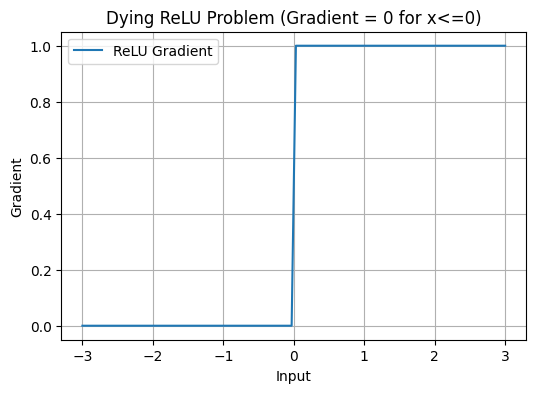

In [21]:
np.random.seed(42)
x = np.linspace(-3, 3, 100)
relu_output = relu(x)
# Simulate "dead" neurons: once output is 0, gradient is 0
grad_relu = np.where(x > 0, 1, 0)

plt.figure(figsize=(6,4))
plt.plot(x, grad_relu, label="ReLU Gradient")
plt.title("Dying ReLU Problem (Gradient = 0 for x<=0)")
plt.xlabel("Input")
plt.ylabel("Gradient")
plt.legend()
plt.grid(True)
plt.show()

# Leaky ReLU

In [22]:
def leaky_relu(x, alpha=0.01):
  return np.where(x > 0, x, alpha * x)

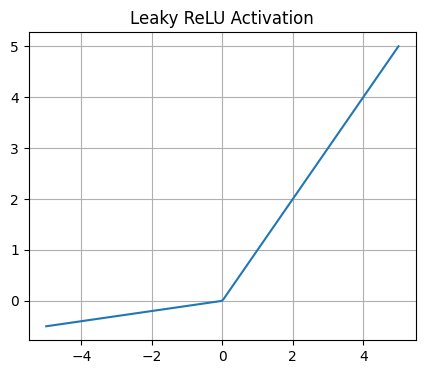

In [24]:
plot_activation(lambda x: leaky_relu(x, alpha=0.1), "Leaky ReLU")
# sklearn MLPClassifier doesn't support leaky relu directly
# We'll skip model training here or handle via custom implementation
results['Leaky ReLU'] = None  # placeholder

# Parametric ReLU (PReLU)

- An extension of Leaky ReLU where the negative slope α is learned from data instead of being fixed.

In [25]:
def prelu(x, alpha=0.25):
  return np.where(x > 0, x, alpha * x)

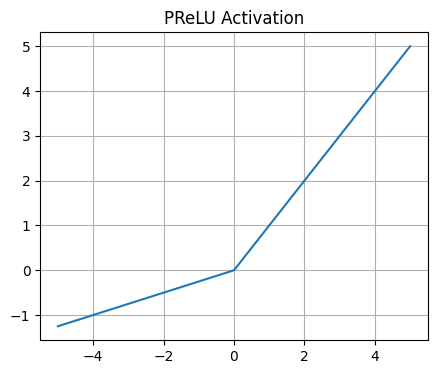

In [27]:
plot_activation(lambda x: prelu(x, alpha=0.25), "PReLU")
results['PReLU'] = None  # placeholder
# We'll skip model training here or handle via custom implementation here we given the alpha directly

# Softmax

In [28]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

In [30]:
softmax(2)

np.float64(1.0)

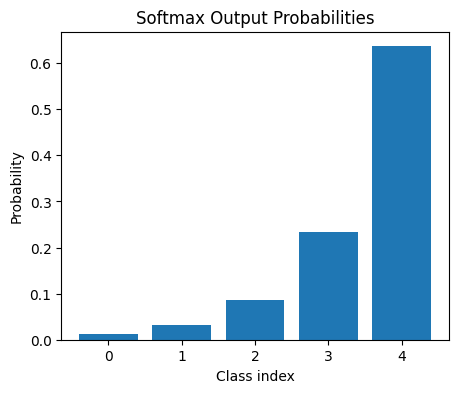

In [31]:
# 7. Softmax Activation (for plotting only)
# Show how it maps logits to probabilities
x_vals = np.linspace(-2, 2, 5)
softmax_outputs = softmax(x_vals)

plt.figure(figsize=(5,4))
plt.bar(range(len(softmax_outputs)), softmax_outputs)
plt.title("Softmax Output Probabilities")
plt.xlabel("Class index")
plt.ylabel("Probability")
plt.show()
results['Softmax'] = None  # placeholder

# Comparision

In [34]:
!pip install tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 17.1 MB/s  0:00:13 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 22.0 MB/s  0:00:00.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 24.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 23.2 MB/s  0:00:013.6 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [tf-keras] 20/21 [tf-keras]w]-py]]


/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3538/3538 ━━━━━━━━━━━━━━━━━━━━ 1s 232us/step


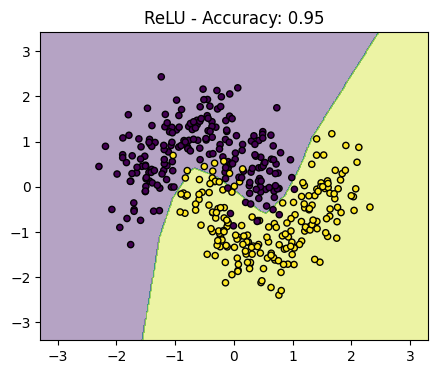

/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3538/3538 ━━━━━━━━━━━━━━━━━━━━ 1s 227us/step


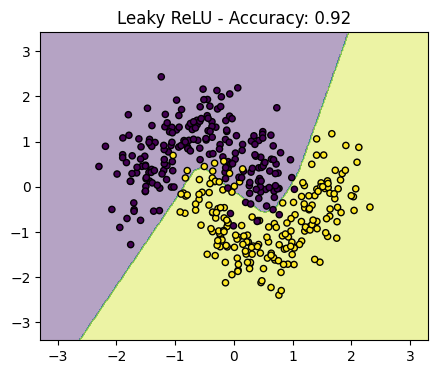

/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
3538/3538 ━━━━━━━━━━━━━━━━━━━━ 1s 226us/step


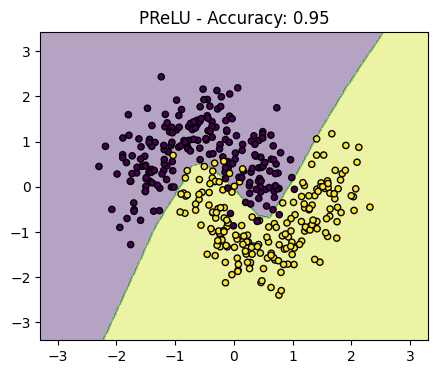

/Users/pulipatipavankumar/softwares/miniconda/envs/ds/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
3538/3538 ━━━━━━━━━━━━━━━━━━━━ 1s 223us/step


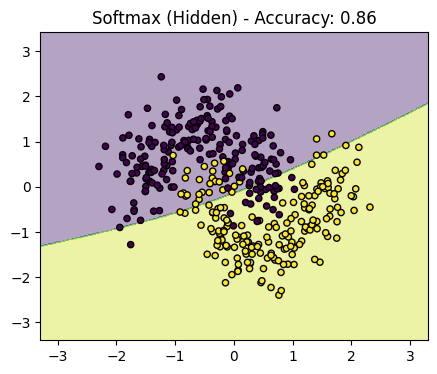

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Activation, PReLU, Softmax

def train_and_plot(activation_type, act_name):

    # 1. Build the model to match your (8,) hidden layer architecture
    model = Sequential()

    model.add(Dense(8, input_dim=2))  # Input layer to Hidden layer (8 units)

    # 2. Add the specific activation
    if activation_type == 'leaky_relu':
        model.add(LeakyReLU(alpha=0.01))

    elif activation_type == 'prelu':
        model.add(PReLU())  # No alpha needed, the model learns it!

    elif activation_type == 'softmax_hidden':
        model.add(Softmax())  # Usually for output, but can be used here

    else:
        model.add(Activation('relu'))

    model.add(Dense(1, activation='sigmoid'))  # Output layer

    # 3. Compile and Fit
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=200,
        batch_size=10,
        verbose=0
    )

    # 4. Predict (Keras returns probabilities, so we round to 0 or 1)
    y_pred = (model.predict(X_test) > 0.5).astype("int32")

    acc = accuracy_score(y_test, y_pred)

    # 5. Decision boundary logic (Matches your original code)
    h = 0.02
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    
    Z = (model.predict(np.c_[xx.ravel(), yy.ravel()]) > 0.5).astype("int32")
    Z = Z.reshape(xx.shape)
    
    # 6. Plotting
    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        s=20,
        edgecolor='k'
    )
    plt.title(f"{act_name} - Accuracy: {acc:.2f}")
    plt.show()
    return acc
    
    
# To plot and compare:
results = {}
results['ReLU'] = train_and_plot('relu', 'ReLU')
results['Leaky ReLU'] = train_and_plot(
    'leaky_relu',
    'Leaky ReLU'
)
results['PReLU'] = train_and_plot(
    'prelu',
    'PReLU'
)
results['Softmax'] = train_and_plot(
    'softmax_hidden',
    'Softmax (Hidden)'
)